# Capstone Project Starter Notebook

## Applied Python for Data Analysis

This notebook is a scaffold for your capstone project. It is designed to help you organize your work, document your thinking, and complete a clear data analysis workflow.

You should replace the placeholder text, complete the TODOs, and add your own analysis throughout.

---

## Capstone Goal

Your project should answer **one clear analytical question** using Python and data.

You will:
- Load and inspect your dataset
- Clean and prepare the data
- Explore the data with summary statistics and visualizations
- Generate insights and recommendations
- Optionally build a simple predictive model


## 1. Problem Statement

Write your problem statement below.

Use the SMART framework:

- **Specific:** What exactly are you trying to answer?
- **Measurable:** What data will you use?
- **Achievable:** Can this be answered with your dataset?
- **Relevant:** Why does this matter?
- **Time-bound:** Is there a time component?

### Problem Statement

> Which customer segments and marketing channels drive the highest revenue and lowest return rates, and what actions should the business take to maximise profitable growth?

### Audience

> Marketing and sales leadership looking to allocate budget across customer acquisition and retention programmes.

### Primary Business / Analytical Question

> Where should the business focus its marketing and retention investment to maximise revenue while minimising product returns?


## 2. Imports and Setup

Run this cell first.

You may add additional libraries if needed.


In [113]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path tools
from pathlib import Path
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. File Paths

Update the file path below so it points to your raw dataset.

Recommended project structure:

```text
data/
├── raw/
│   └── your_dataset.csv
└── processed/
    └── cleaned_dataset.csv
```


In [114]:
# Paths relative to the notebook location
BASE_DIR     = Path().resolve().parent
DATA_RAW     = BASE_DIR / "data" / "raw"
DATA_PROC    = BASE_DIR / "data" / "processed"
FIGURES_DIR  = BASE_DIR / "outputs" / "figures"

# Ensure output directories exist
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = DATA_RAW / "capstone_dataset.csv"
print(f"Raw data path: {RAW_FILE}")
print(f"File exists:   {RAW_FILE.exists()}")

Raw data path: C:\Users\datar\OneDrive\Areas\Training\General Assembly - Python for Ai and data\capstone-pad\data\raw\capstone_dataset.csv
File exists:   True


## 4. Load the Dataset

Load your dataset into a pandas DataFrame.

If your file is not a CSV, adjust the code accordingly.


In [115]:
df = pd.read_csv(RAW_FILE)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 500 rows × 13 columns


,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0


## 5. Initial Data Inspection

Use this section to understand the basic structure of your dataset.

Questions to answer:
- How many rows and columns are there?
- What does each row represent?
- What are the column names?
- What data types are present?
- Are there missing values?


In [116]:
# Shape of the dataset
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")


Rows: 500   Columns: 13


In [117]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         500 non-null    object 
 1   date                   500 non-null    object 
 2   customer_id            500 non-null    object 
 3   customer_segment       500 non-null    object 
 4   product_category       500 non-null    object 
 5   product_price          500 non-null    float64
 6   quantity               500 non-null    int64  
 7   discount_applied       495 non-null    float64
 8   marketing_channel      500 non-null    object 
 9   region                 500 non-null    object 
 10  total_revenue          500 non-null    float64
 11  customer_satisfaction  490 non-null    float64
 12  returned               500 non-null    int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 50.9+ KB


In [118]:
# Data types and missing values
df.isnull().sum()


transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [119]:
# Summary statistics for numeric columns
df.describe()


,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned
count,500.000000,500.000000,495.000000,500.000000,490.000000,500.000000
mean,266.594660,3.032000,0.075051,769.146000,3.865306,0.072000
std,142.045942,1.423738,0.070773,594.522332,0.638105,0.258747
min,15.120000,1.000000,0.000000,10.000000,2.000000,0.000000
25%,146.555000,2.000000,0.000000,282.042500,3.000000,0.000000
50%,272.035000,3.000000,0.050000,644.250000,4.000000,0.000000
75%,389.152500,4.000000,0.125000,1181.647500,4.000000,0.000000
max,499.690000,5.000000,0.250000,2469.200000,5.000000,1.000000


In [120]:
# Summary statistics for non-numeric columns
df.describe(include=['object'])



,transaction_id,date,customer_id,customer_segment,product_category,marketing_channel,region
count,500,500,500,500,500,500,500
unique,500,268,472,3,6,6,5
top,TXN-00211,2025-08-05,CUST-2552,Returning,Beauty,Direct,West
freq,1,8,4,210,94,95,108


In [121]:
# Missing values by column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing_counts)


Columns with missing values:
customer_satisfaction    10
discount_applied          5
dtype: int64


In [122]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")



Number of duplicate rows: 0


## 6. Data Cleaning

Use this section to clean your dataset.

Common cleaning tasks:
- Fix column names
- Convert data types
- Handle missing values
- Remove duplicates
- Fix inconsistent categories
- Create helpful new columns

Document every major cleaning decision in markdown.


In [123]:
# Make a copy before cleaning
df_clean = df.copy()

In [124]:
# standardize column names
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')



In [125]:
# Convert date columns if your dataset has them

df_clean["date"] = pd.to_datetime(df_clean["date"])




In [126]:
# Handle missing values

df_clean["customer_satisfaction"] = df_clean["customer_satisfaction"].fillna(
    df_clean["customer_satisfaction"].median()  # Fill with median value
)

# Convert returned column to integers (0 or 1)
df_clean["returned"] = df_clean["returned"].astype(int)

In [127]:
# Remove duplicate rows if appropriate

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Rows removed: {before - len(df_clean)}   Rows remaining: {len(df_clean):,}")



Rows removed: 0   Rows remaining: 500


In [128]:
#  Check categorical columns for inconsistent labels

print("discount_applied values:", sorted(df_clean["discount_applied"].unique()))
print("customer_satisfaction values:", sorted(df_clean["customer_satisfaction"].unique()))



discount_applied values: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(nan)]
customer_satisfaction values: [np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [129]:
# create new useful columns

df_clean["estimated_revenue"] = (
    df_clean["product_price"] 
    * df_clean["quantity"] 
    * (1 - df_clean["discount_applied"])
)

# Create a new helper column: readable discount label (e.g. "10%")
df_clean["discount_pct"] = (
    df_clean["discount_applied"].fillna(0) * 100
).astype(int).astype(str) + "%"




### Cleaning Summary

Write a short summary of your cleaning steps.

>
**Converted `date` to datetime** -> Enables time-aware operations if needed 
**Cast `returned` to integer** -> Ensures `.sum()` correctly counts returns |
**Dropped duplicate rows** -> Prevents double-counting in aggregations 
**Added `estimated_revenue`, `discount_pct`** -> Helper columns , more readable


In [130]:
# Save cleaned dataset
DATA_PROC = BASE_DIR / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(DATA_PROC / "cleaned_dataset.csv", index=False)
print(f"Cleaned dataset saved — {len(df_clean):,} rows")


Cleaned dataset saved — 500 rows


## 7. Exploratory Data Analysis

Use EDA to answer your main question.

Your project should include:
- Summary statistics
- At least 2 meaningful visualizations
- At least 2 strong insights
- Clear interpretation of each chart or table

Do not just make charts. Explain what they mean.


### 7.1 Univariate Analysis

Analyze one variable at a time.

Examples:
- Distribution of revenue
- Count of product categories
- Count of customer segments
- Distribution of sale prices


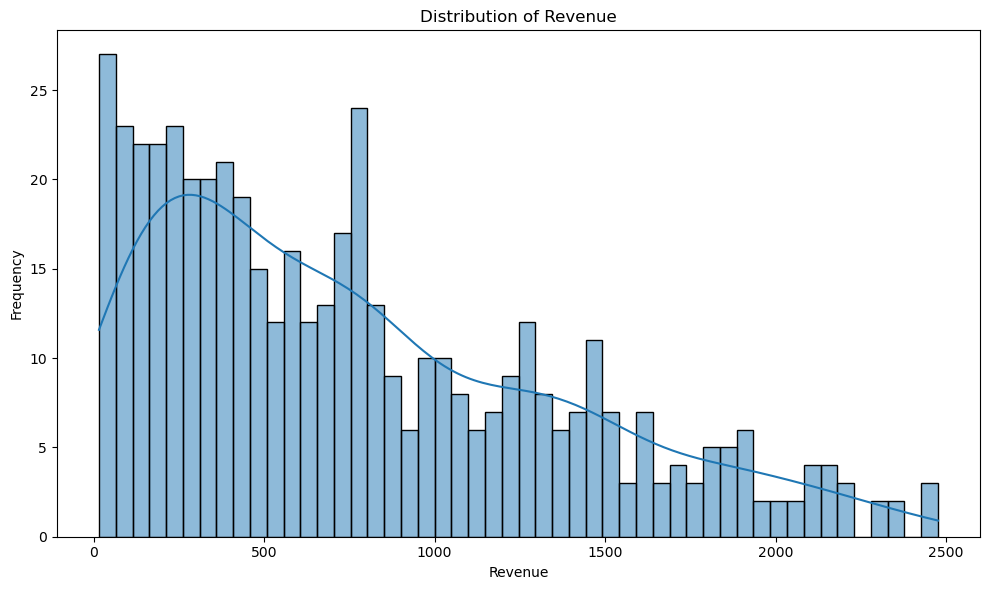

In [163]:
# Choose a numeric column to visualize
# Example: distribution of total revenue
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["estimated_revenue"], bins=50, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "revenue_distribution.png")
plt.show()


**Observation:** Revenue per transaction is right-skewed — the majority of transactions are under $1,000.

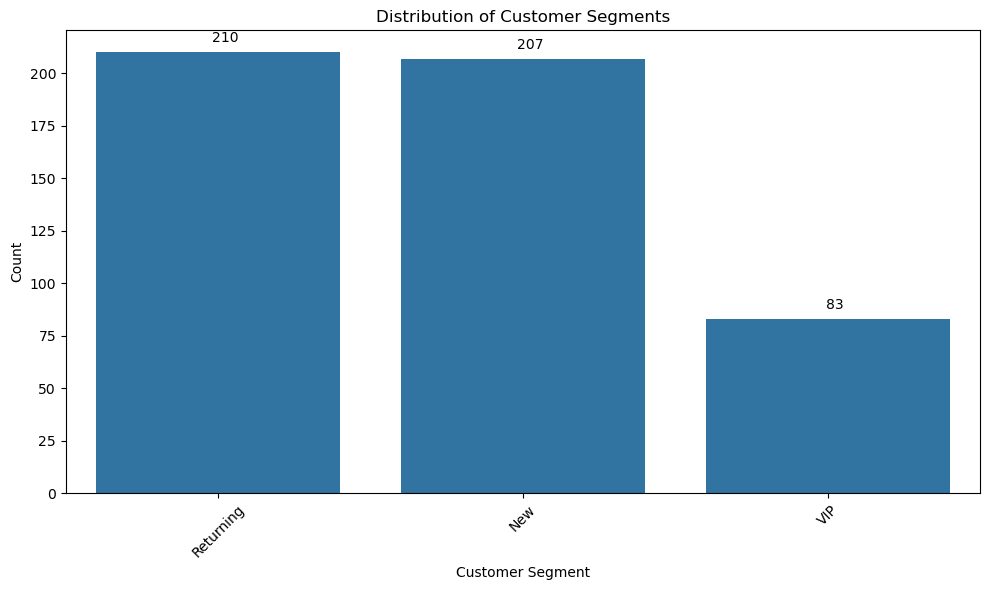

In [187]:
# Choose a categorical column to visualize
# Example: distribution of customer segments
plt.figure(figsize=(10, 6))
ax=sns.countplot(x="customer_segment", data=df_clean, order=df_clean["customer_segment"].value_counts().index)
plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "customer_segment_distribution.png")

# Add data labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.0f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(5,5),                       # slight upward offset
        textcoords='offset points'
    )
plt.show()

**Observation:** Returning customers make up the largest share of transactions, followed by New and VIP customers.

### 7.2 Group-Based Analysis

Use `.groupby()` to compare groups.

Examples:
- Average revenue by customer segment
- Return rate by product category
- Average price by neighborhood
- Life expectancy by continent


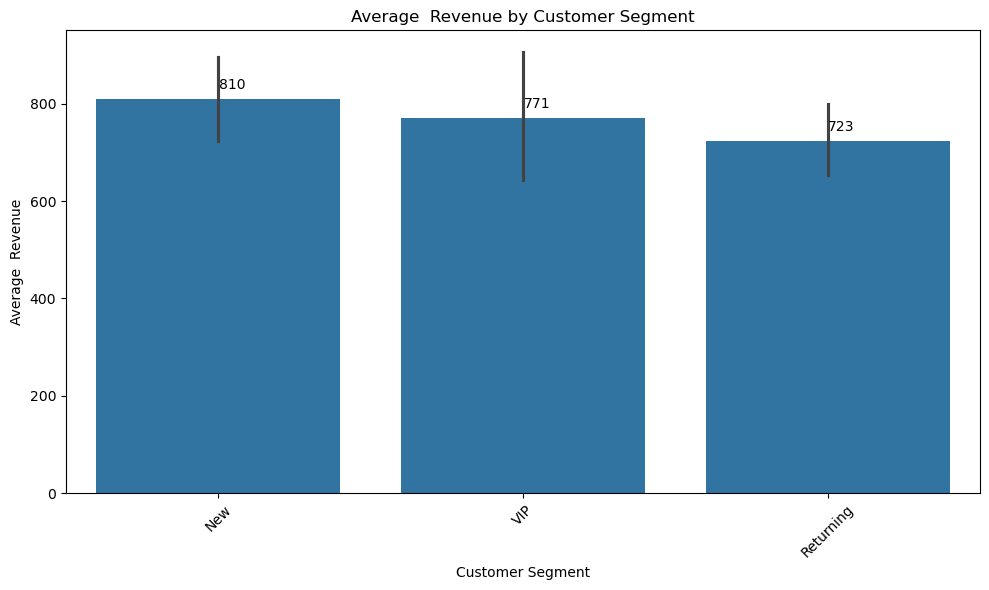

In [196]:
# Average revenue by customer segment
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="customer_segment", y="estimated_revenue", data=df_clean, order=df_clean.groupby("customer_segment")["estimated_revenue"].mean().sort_values(ascending=False).index) 
plt.title("Average  Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average  Revenue")
plt.xticks(rotation=45)
plt.tight_layout()  
# Add data labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.0f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(10,5),                       # slight upward offset
        textcoords='offset points'
    )

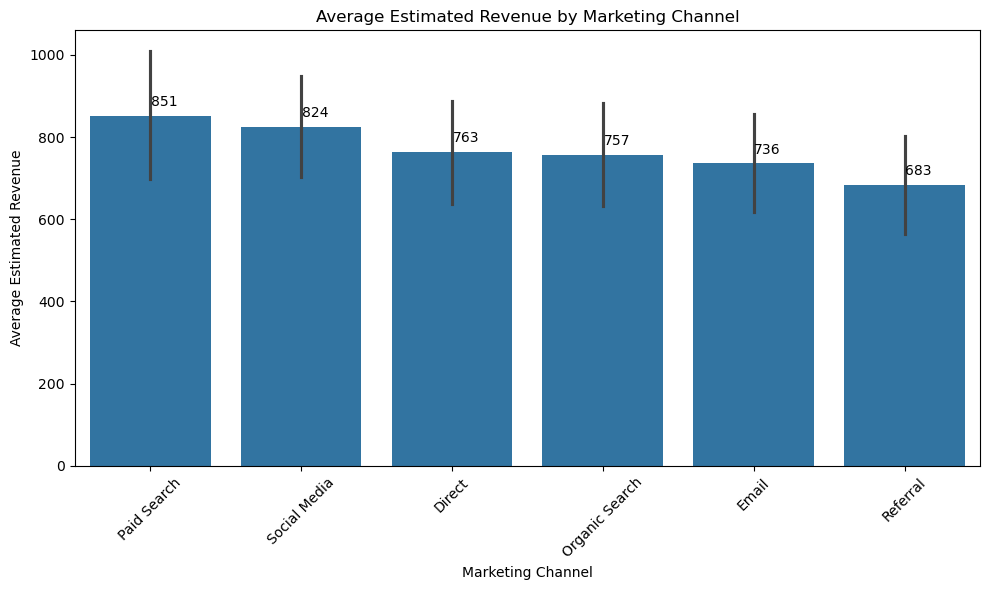

In [145]:
#Average revenue by marketing channel
plt.figure(figsize=(10, 6))
ax=sns.barplot(x="marketing_channel", y="estimated_revenue", data=df_clean, order=df_clean.groupby("marketing_channel")["estimated_revenue"].mean().sort_values(ascending=False).index)
plt.title("Average Estimated Revenue by Marketing Channel") 
plt.xlabel("Marketing Channel")
plt.ylabel("Average Estimated Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "marketing_channel_revenue.png")

# Add data labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.0f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(10,5),                       # slight upward offset
        textcoords='offset points'
    )

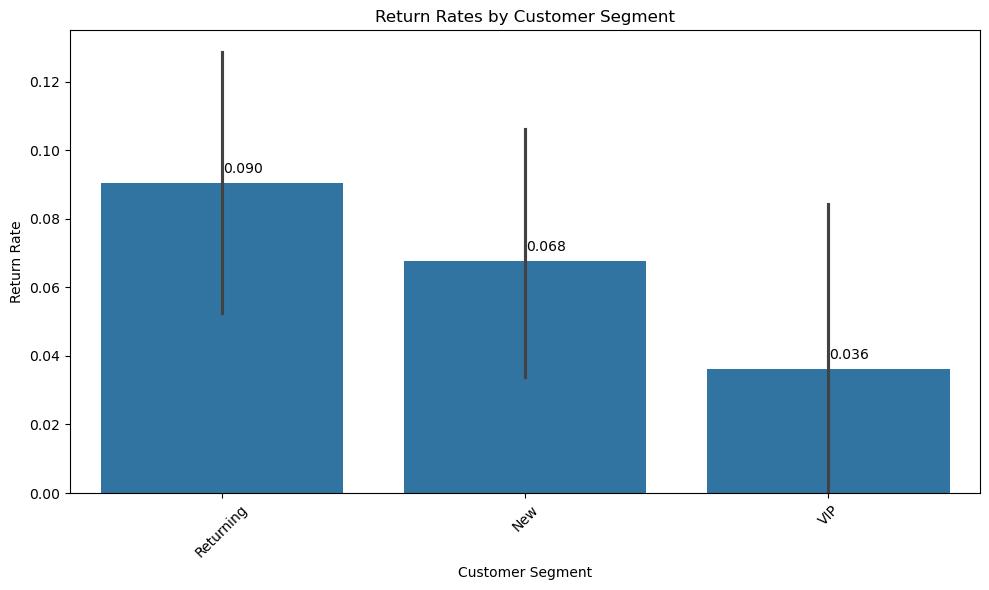

In [176]:
#return rates by customer segment
plt.figure(figsize=(10, 6))
ax=sns.barplot(x="customer_segment", y="returned", data=df_clean, order=df_clean.groupby("customer_segment")["returned"].mean().sort_values(ascending=False).index)
plt.title("Return Rates by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "return_rates_by_customer_segment.png")

# Add data labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.3f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(15,5),                       # slight upward offset
        textcoords='offset points'
    )
plt.show()

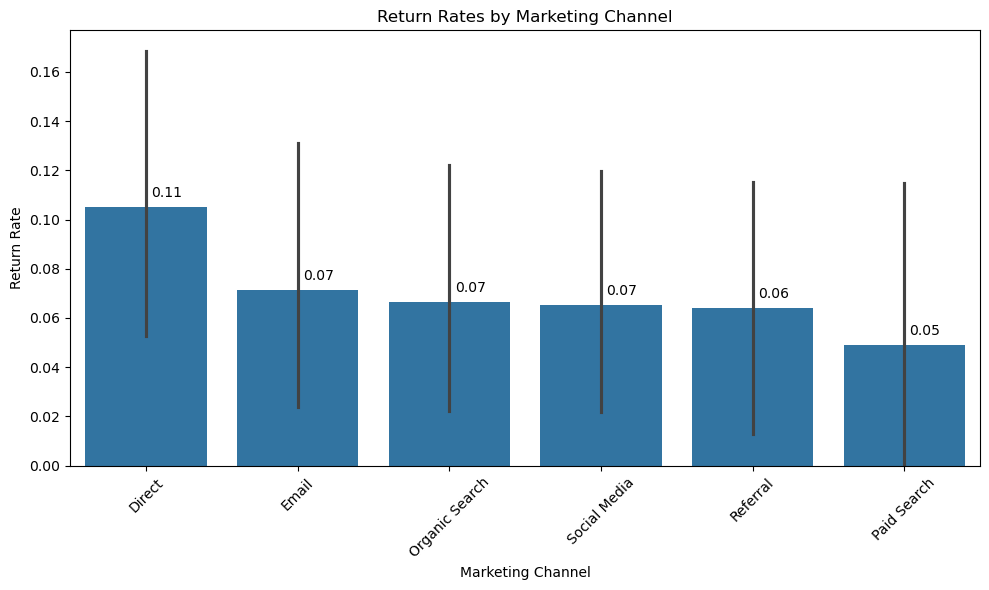

In [174]:
# return rates by marketing channel
plt.figure(figsize=(10, 6))
ax=sns.barplot(x="marketing_channel", y="returned", data=df_clean, order=df_clean.groupby("marketing_channel")["returned"].mean().sort_values(ascending=False).index)
plt.title("Return Rates by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "return_rates_by_marketing_channel.png")


# Add data labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.2f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(15,5),                       # slight upward offset
        textcoords='offset points'
    )
plt.show()


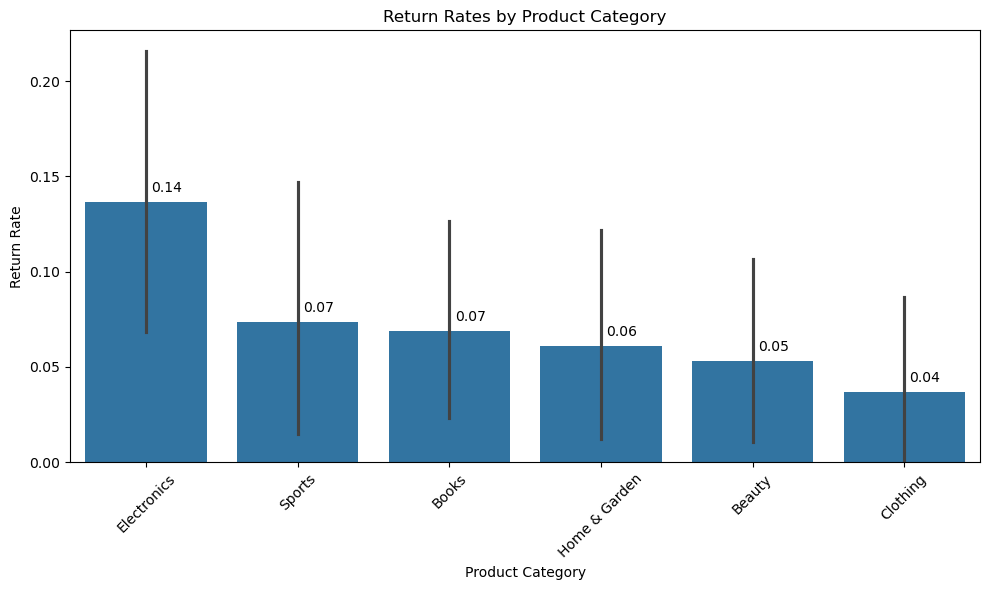

In [173]:
#return rates by product category
plt.figure(figsize=(10, 6))
ax=sns.barplot(x="product_category", y="returned", data=df_clean, order=df_clean.groupby("product_category")["returned"].mean().sort_values(ascending=False).index)
plt.title("Return Rates by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "return_rates_by_product_category.png")
# Add data labels
for p in ax.patches:                
    value = p.get_height()
    ax.annotate(
        f"{value:,.2f}",                     # formatted label
        (p.get_x() + p.get_width() / 2, value),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(15,5),                       # slight upward offset
        textcoords='offset points'
    )
plt.show()

### 7.3 Relationship Analysis

Explore relationships between variables.

Examples:
- Revenue vs discount
- Sale price vs square footage
- Satisfaction vs return status


In [166]:
# Group by discount_pct, calculate return rate
df_clean.groupby("discount_pct")["returned"].mean()

#Tests whether heavy discounting attracts returners

discount_pct
0%     0.084337
10%    0.061856
15%    0.062500
20%    0.125000
25%    0.100000
5%     0.053097
Name: returned, dtype: float64

<Axes: xlabel='returned', ylabel='customer_satisfaction'>

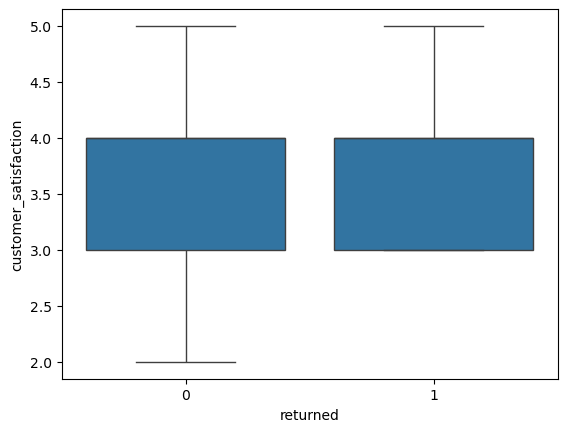

In [167]:
# Customer satisfaction vs return status
sns.boxplot(x="returned", y="customer_satisfaction", data=df_clean)

#Confirms whether low satisfaction predicts returns — validates satisfaction as a leading indicator.

In [169]:
summary = df_clean.groupby(["customer_segment", "marketing_channel"]).agg(
    avg_revenue=("estimated_revenue", "mean"),
    return_rate=("returned", "mean"),
    transaction_count=("transaction_id", "count")
).round(2)

In [170]:
# Display with readable formatting
summary.style.format({
    "avg_revenue":      "${:,.0f}",
    "return_rate":      "{:.1%}",
    "num_transactions": "{:,}"
})

In [171]:
print("=== Top 5 combinations by revenue ===")
print(summary["avg_revenue"].head(5).to_string())

print("\n=== Top 5 combinations by lowest return rate ===")
print(summary["return_rate"].sort_values().head(5).to_string())

=== Top 5 combinations by revenue ===
customer_segment  marketing_channel
New               Direct               811.00
                  Email                632.52
                  Organic Search       953.50
                  Paid Search          929.41
                  Referral             687.28

=== Top 5 combinations by lowest return rate ===
customer_segment  marketing_channel
VIP               Direct               0.00
                  Paid Search          0.00
                  Referral             0.00
New               Email                0.03
                  Organic Search       0.03


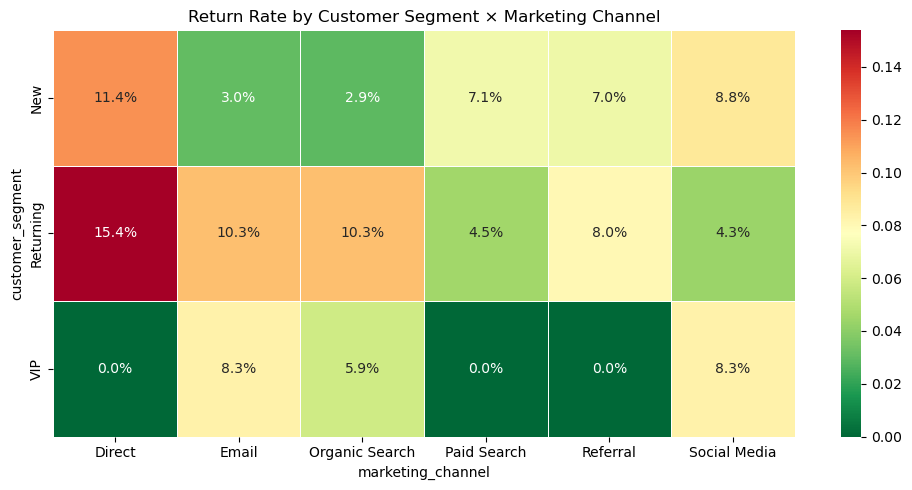

In [197]:
import matplotlib.ticker as mticker

pivot = df_clean.pivot_table(
    values="returned", index="customer_segment",
    columns="marketing_channel", aggfunc="mean"
)
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=0.5)
plt.title("Return Rate by Customer Segment × Marketing Channel")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_return_rate_segment_channel.png")
plt.show()

A heatmap maps colour intensity to value — the darkest cells (worst combinations) and lightest cells (best) without reading every number. 

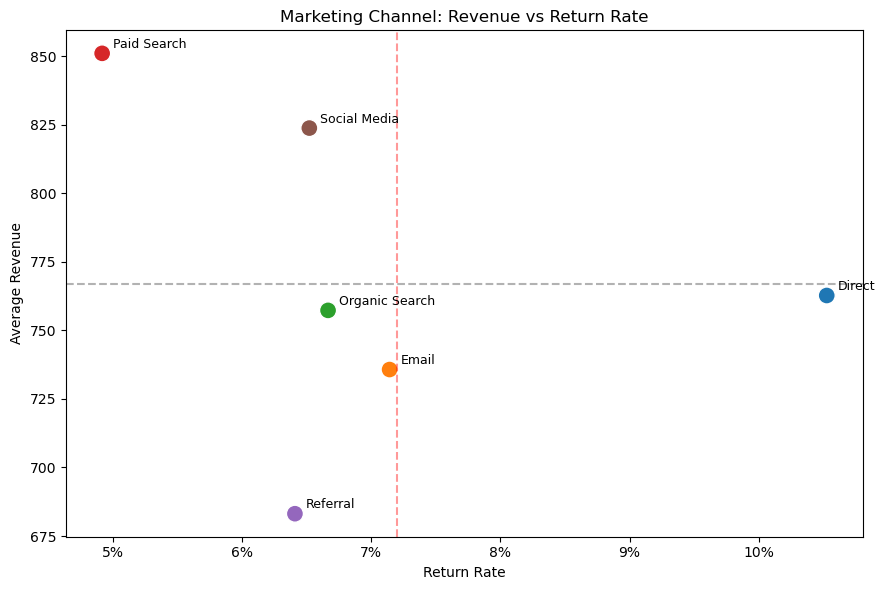

In [198]:
channel_summary = df_clean.groupby("marketing_channel").agg(
    avg_revenue=("estimated_revenue", "mean"),
    return_rate=("returned", "mean")
).reset_index()

plt.figure(figsize=(9, 6))
ax = sns.scatterplot(data=channel_summary, x="return_rate", y="avg_revenue",
                     s=150, hue="marketing_channel", palette="tab10", legend=False)
for _, row in channel_summary.iterrows():
    ax.annotate(row["marketing_channel"],
                (row["return_rate"], row["avg_revenue"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.axhline(df_clean["estimated_revenue"].mean(), linestyle="--", color="grey", alpha=0.6, label="Avg revenue")
plt.axvline(df_clean["returned"].mean(), linestyle="--", color="red", alpha=0.4, label="Avg return rate")
plt.title("Marketing Channel: Revenue vs Return Rate")
plt.xlabel("Return Rate")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_channel_revenue_vs_returns.png")
plt.show()

## 8. Insights and Recommendations

Use this section to turn your analysis into conclusions.

Avoid weak observations like:

> VIP customers have higher revenue.

Instead, write stronger insights:

> VIP customers generate higher average revenue and lower return rates, suggesting that retention campaigns focused on VIP customers may produce strong business value.

### Insight 1

> VIP customers are the most capital-efficient segment — generating near-average revenue while returning products at less than half the overall rate (3.6% vs 7.2%). Despite this, they represent only 1 in 6 transactions. Increasing VIP engagement frequency would grow revenue without proportionally increasing return costs.

### Recommendation 1

>  Launch a VIP retention programme (loyalty rewards, early access, personalised offers) to convert one-off VIP buyers into repeat purchasers.

### Insight 2

> Paid Search is the strongest channel; Direct is the weakest.
Paid Search is the most profitable acquisition channel — $851 average revenue at only 4.9% returns — while Direct channel costs the business disproportionately through a 10.5% return rate on below-average revenue ($763). Reallocating budget from Direct to Paid Search and Social Media would improve both revenue and margin.

### Recommendation 2

> Audit what is driving Direct channel returns (product mismatch, unclear expectations, no pre-purchase filtering). Shift budget toward Paid Search and Social Media.


## 9. Optional: Working With Multiple Datasets

Only use this section if your project includes more than one dataset.

Use `pd.merge()` when two datasets share a common key.


In [133]:
# Example merge pattern

# left_df = pd.read_csv(DATA_RAW / "left_dataset.csv")
# right_df = pd.read_csv(DATA_RAW / "right_dataset.csv")

# merged_df = pd.merge(
#     left_df,
#     right_df,
#     on="shared_key_column",
#     how="inner"
# )

# merged_df.head()


## 10. Optional: Simple Modeling

Modeling is optional for this capstone.

Only include a model if it supports your main question.

Keep it simple:
- Linear Regression for numeric prediction
- Logistic Regression for classification

Focus on explaining what you tried and what you learned.


### Modeling Summary

If you included a model, answer:

- What were you trying to predict?
- What features did you use?
- How did the model perform?
- What are the limitations?
- Did the model help answer your main question?

> TODO: Write your modeling summary here.


## 11. Final Project Summary

Use this section to summarize your project.

Your final summary should include:

1. Problem statement
2. Dataset used
3. Main analysis steps
4. Key insights
5. Recommendations
6. Limitations
7. Future work

You should also save a short version of this summary in:

```text
docs/project_summary.md
```


### Final Summary

> TODO: Write your final project summary here.


## 12. Final Notebook Checklist

Before submitting:

- [ ] Notebook runs from top to bottom without errors
- [ ] Problem statement is clear
- [ ] Dataset is loaded from a relative path
- [ ] Cleaning steps are documented
- [ ] At least 2 visualizations are included
- [ ] At least 2 insights are clearly explained
- [ ] Recommendations are tied to evidence
- [ ] Cleaned dataset is saved
- [ ] Project summary is completed
- [ ] Files are organized in the required repo structure
